# TropiCycloneNet Test Dataset Exploratory Data Analysis
**Basin Generalization for Tropical Cyclone Track & Intensity Forecasting**

In [58]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import xarray as xr
import warnings
warnings.filterwarnings('ignore')

ROOT = '/Users/arshadpatel2001/Desktop/Desktop/Imperial/MLfTCC/Project/data/tropicyclonenet/TCND_test'

BASINS  = ['EP', 'NA', 'NI', 'SI', 'SP', 'WP']
COLORS  = {'EP': '#4dac26', 'NA': '#d6604d', 'NI': '#80b1d3', 'SI': '#f4a582', 'SP': '#f4a582', 'WP': '#2166ac'}
SPLIT   = 'test'

# Data1D column names
COLS = ["ID", "FLAG", "LAT_raw", "LONG_norm", "WND_norm", "PRES_norm", "YYYYMMDDHH", "Name"]

print(f'TCND root: {ROOT}')
print('Basins:', BASINS)

TCND root: /Users/arshadpatel2001/Desktop/Desktop/Imperial/MLfTCC/Project/data/tropicyclonenet/TCND_test
Basins: ['EP', 'NA', 'NI', 'SI', 'SP', 'WP']


## 1. Load All Data1D Records

In [59]:
def load_basin_1d(basin):
    pattern = os.path.join(ROOT, 'Data1D', basin, SPLIT, '*.txt')
    files = sorted(glob.glob(pattern))
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f, sep='\t', header=None, names=COLS)
            # Parse TC name and year from filename: e.g. WP2017BSTBANYAN.txt
            stem = os.path.basename(f).replace('.txt', '')
            year = int(stem[2:6])
            tc_name = stem[9:] if 'BST' in stem else stem[6:]
            df['basin']   = basin
            df['year']    = year
            df['tc_name'] = tc_name
            dfs.append(df)
        except Exception as e:
            print(f'  skip {f}: {e}')
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

all_dfs = {b: load_basin_1d(b) for b in BASINS}
df_all  = pd.concat(all_dfs.values(), ignore_index=True)

df_all["lat_deg"]  = df_all["LAT_raw"]*1800.0 - 900.0
df_all["lon_deg"]  = df_all["LONG_norm"] * 3600.0
df_all["wnd_ms"]   = df_all["WND_norm"] * 100.0
df_all["pres_hpa"] = df_all["PRES_norm"] * 1080.0 + 870.0

# Parse datetime
df_all['datetime'] = pd.to_datetime(df_all['YYYYMMDDHH'].astype(str), format='%Y%m%d%H', errors='coerce')
df_all['month']    = df_all['datetime'].dt.month

print(f'Total records: {len(df_all):,}')
print(f'Unique storms: {df_all.groupby(["basin","tc_name"]).ngroups}\n')
for b in BASINS:
    sub = df_all[df_all.basin == b]
    storms = sub.groupby('tc_name').ngroups
    print(f'{b}: {storms} storms, {len(sub):,} timesteps')

Total records: 16,110
Unique storms: 456

EP: 93 storms, 3,345 timesteps
NA: 101 storms, 3,900 timesteps
NI: 20 storms, 527 timesteps
SI: 81 storms, 2,854 timesteps
SP: 30 storms, 922 timesteps
WP: 131 storms, 4,562 timesteps


In [60]:
df_all.head()

,ID,FLAG,LAT_raw,LONG_norm,WND_norm,PRES_norm,YYYYMMDDHH,Name,basin,year,tc_name,lat_deg,lon_deg,wnd_ms,pres_hpa,datetime,month
0,0.0,1.0,16.70,2.56,0.96,-1.086,2017062400,DORA,EP,2017,DORA,29160.0,9216.0,96.0,-302.88,2017-06-24 00:00:00,6
1,1.0,1.0,16.56,2.60,0.96,-1.086,2017062406,DORA,EP,2017,DORA,28908.0,9360.0,96.0,-302.88,2017-06-24 06:00:00,6
2,2.0,1.0,16.42,2.64,0.96,-1.086,2017062412,DORA,EP,2017,DORA,28656.0,9504.0,96.0,-302.88,2017-06-24 12:00:00,6
3,3.0,1.0,16.26,2.72,0.94,-1.086,2017062418,DORA,EP,2017,DORA,28368.0,9792.0,94.0,-302.88,2017-06-24 18:00:00,6
4,4.0,1.0,16.10,2.80,0.92,-0.983,2017062500,DORA,EP,2017,DORA,28080.0,10080.0,92.0,-191.64,2017-06-25 00:00:00,6


## 2. Summary Statistics Table

In [61]:
stats = []
for b in BASINS:
    sub = df_all[df_all.basin == b]
    storms = sub['tc_name'].nunique()
    stats.append({
        'Basin': b,
        'Storms': storms,
        'Timesteps': len(sub),
        'Wind mean (m/s)': f"{sub.wnd_ms.mean():.1f}",
        'Wind max (m/s)':  f"{sub.wnd_ms.max():.1f}",
        'Pressure min (hPa)': f"{sub.pres_hpa.min():.0f}",
        'Latitude range': f"{sub.lat_deg.min():.1f}°–{sub.lat_deg.max():.1f}°",
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

Basin  Storms  Timesteps Wind mean (m/s) Wind max (m/s) Pressure min (hPa)      Latitude range
   EP      93       3345            71.2          116.0               -524    -828.0°–33336.0°
   NA     101       3900            65.1          122.0               -524   27792.0°–63900.0°
   NI      20        527            56.4           92.0               -413 -50272.2°–-32580.0°
   SI      81       2854            60.9          102.0               -636 -54126.0°–-17114.4°
   SP      30        922            50.2           98.0               -524   -17100.0°–6876.0°
   WP     131       4562            46.3          100.0               -426   -30204.0°–-936.0°


## 3. Intensity Classification (Rapid Intensification Labels)

In [62]:
# Load env data to get RI labels (future_inte_change24)
# RI defined as future_inte_change24 == 3 (strong intensification class)
ri_counts = {}
total_counts = {}

for basin in BASINS:
    env_pattern = os.path.join(ROOT, 'Env-Data', basin, '**', '*.npy')
    env_files = glob.glob(env_pattern, recursive=True)
    ri = 0; total = 0
    for ef in env_files:
        try:
            d = np.load(ef, allow_pickle=True).item()
            label = int(d.get('future_inte_change24', -1))
            if label >= 0:
                total += 1
                if label == 3:
                    ri += 1
        except:
            pass
    ri_counts[basin] = ri
    total_counts[basin] = total
    print(f'{basin}: {ri}/{total} RI events ({100*ri/max(total,1):.1f}%)')

EP: 367/2928 RI events (12.5%)
NA: 515/3465 RI events (14.9%)
NI: 38/447 RI events (8.5%)
SI: 281/2515 RI events (11.2%)
SP: 84/802 RI events (10.5%)
WP: 532/3982 RI events (13.4%)


## 4. Figure 1 — Wind Speed & Pressure Distributions

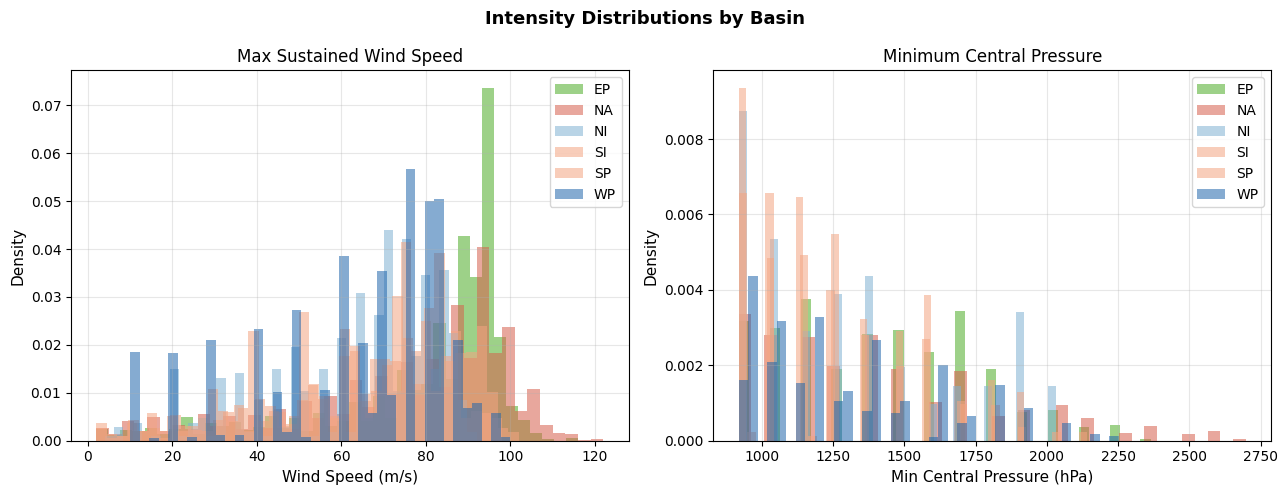

Saved: fig2_distributions.png


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Intensity Distributions by Basin', fontsize=13, fontweight='bold')

# Wind speed
ax = axes[0]
for basin in BASINS:
    sub = df_all[df_all.basin == basin]
    vals = sub.wnd_ms[sub.wnd_ms > 0]
    ax.hist(vals, bins=40, alpha=0.55, label=basin, color=COLORS[basin], density=True)
ax.set_xlabel('Wind Speed (m/s)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Max Sustained Wind Speed')
ax.legend()
ax.grid(True, alpha=0.3)

# RI threshold marker

# Pressure
ax = axes[1]
for basin in BASINS:
    sub = df_all[df_all.basin == basin]
    vals = sub.pres_hpa[sub.pres_hpa > 870]
    ax.hist(vals, bins=40, alpha=0.55, label=basin, color=COLORS[basin], density=True)
ax.set_xlabel('Min Central Pressure (hPa)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Minimum Central Pressure')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_distributions.png')

## 5. Figure 2 — Seasonality (Monthly Storm Frequency)

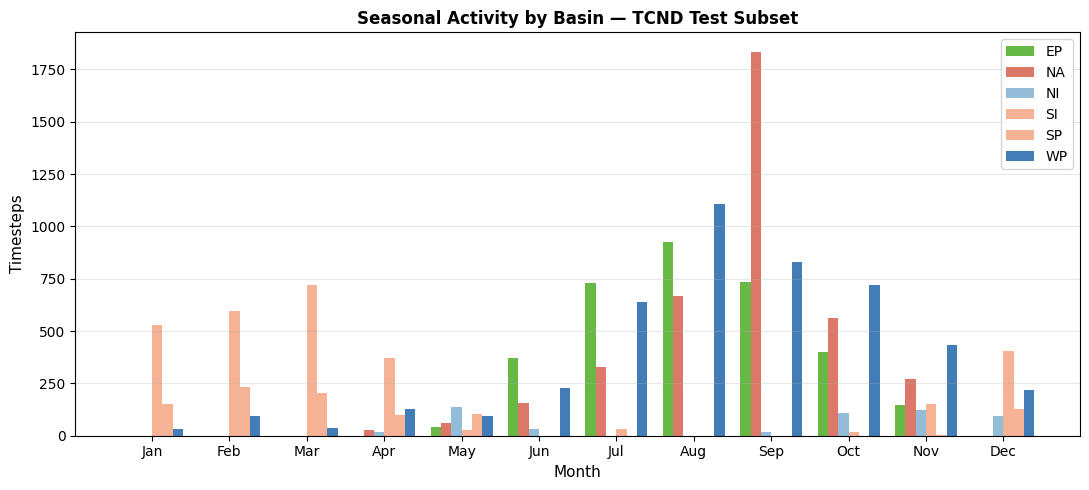

Saved: fig3_seasonality.png


In [64]:
fig, ax = plt.subplots(figsize=(11, 5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

width = 0.8 / len(BASINS)
x = np.arange(12)
for i, basin in enumerate(BASINS):
    sub = df_all[df_all.basin == basin]
    counts = sub.groupby('month').size().reindex(range(1,13), fill_value=0)
    ax.bar(x - 0.4 + (i + 0.5)*width, counts.values, width=width, label=basin,
           color=COLORS[basin], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Timesteps', fontsize=11)
ax.set_title('Seasonal Activity by Basin — TCND Test Subset', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_seasonality.png')

## 6. Figure 3 — SST Snapshot from Data3D (one TC)

Variables: ['u', 'v', 'z', 'sst']
Dims: {'time': 1, 'pressure_level': 4, 'latitude': 81, 'longitude': 81}


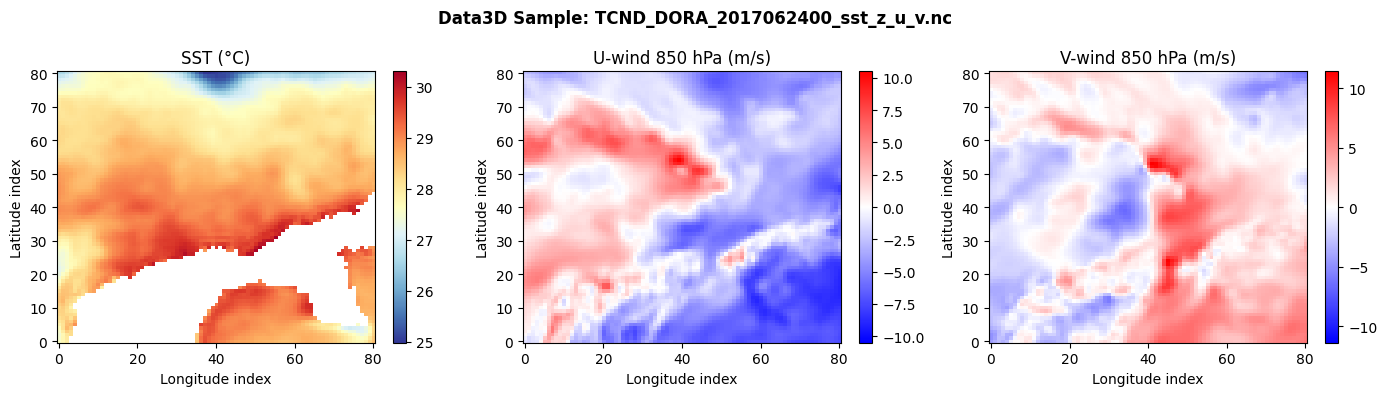

Saved: fig4_spatial.png


In [65]:
# Load one NetCDF to visualise multimodal spatial data
nc_pattern = os.path.join(ROOT, 'Data3D', 'EP', '2017', 'DORA', '*.nc')
nc_files = sorted(glob.glob(nc_pattern))

if not nc_files:
    # Try any basin
    nc_files = sorted(glob.glob(os.path.join(ROOT, 'Data3D', '**', '*.nc'), recursive=True))[:1]

if nc_files:
    ds = xr.open_dataset(nc_files[0])
    print('Variables:', list(ds.data_vars))
    print('Dims:', dict(ds.dims))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fname = os.path.basename(nc_files[0])
    fig.suptitle(f'Data3D Sample: {fname}', fontsize=12, fontweight='bold')

    # SST
    sst = ds['sst'].values.squeeze().astype(float)
    sst[sst > 1e10] = np.nan
    sst_c = sst - 273.15
    im0 = axes[0].imshow(sst_c, cmap='RdYlBu_r', origin='lower', aspect='auto')
    axes[0].set_title('SST (°C)')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    # U-wind at 850 hPa
    u850 = ds['u'].values.squeeze()
    if u850.ndim == 3:     # (pressure, H, W)
        u850 = u850[2]     # 850 hPa is index 2 of [200,500,850,925]
    immax = max(abs(np.nanmin(u850)), abs(np.nanmax(u850))) if np.any(~np.isnan(u850)) else 1.0; im1 = axes[1].imshow(u850, cmap='bwr', origin='lower', aspect='auto', vmin=-immax, vmax=immax)
    axes[1].set_title('U-wind 850 hPa (m/s)')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    # V-wind at 850 hPa
    v850 = ds['v'].values.squeeze()
    if v850.ndim == 3:
        v850 = v850[2]
    immax = max(abs(np.nanmin(v850)), abs(np.nanmax(v850))) if np.any(~np.isnan(v850)) else 1.0; im2 = axes[2].imshow(v850, cmap='bwr', origin='lower', aspect='auto', vmin=-immax, vmax=immax)
    axes[2].set_title('V-wind 850 hPa (m/s)')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    for ax in axes:
        ax.set_xlabel('Longitude index'); ax.set_ylabel('Latitude index')

    plt.tight_layout()
    plt.savefig('fig4_spatial.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fig4_spatial.png')
    ds.close()
else:
    print('No NetCDF files found — check DATA_ROOT')

## 7. Figure 4 — Intensity Class Imbalance (RI is rare!)

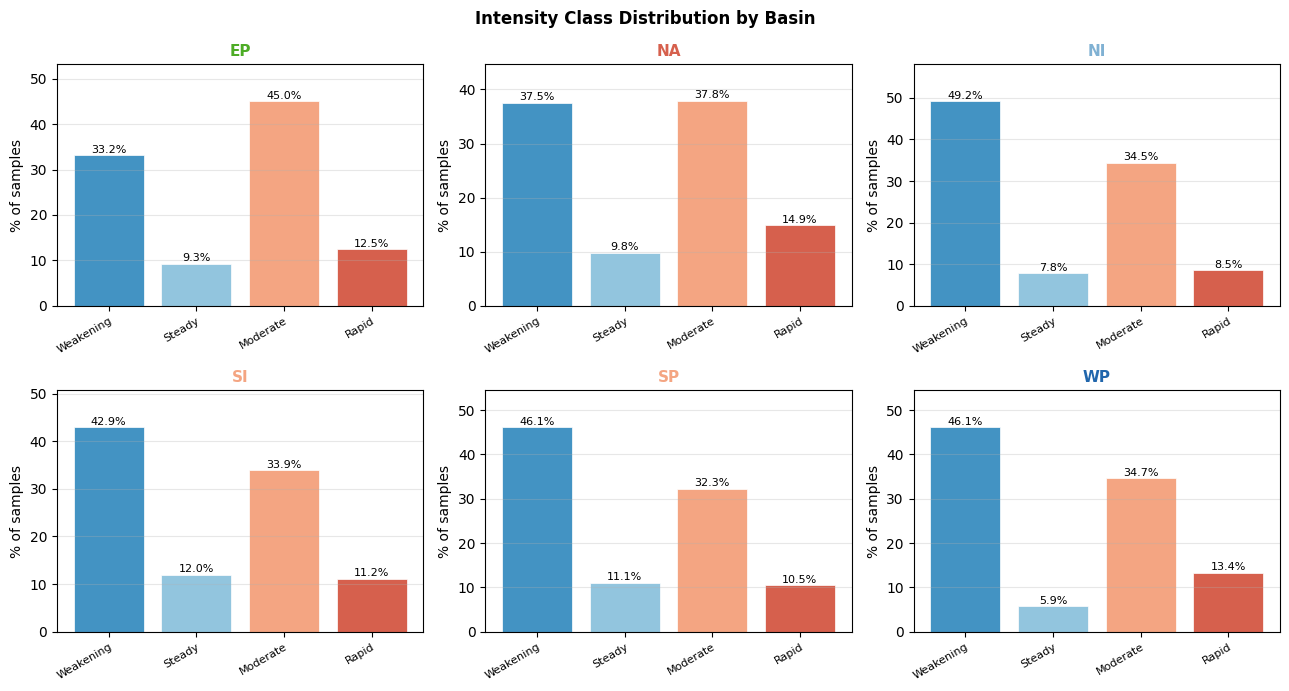

In [75]:
class_labels = ['Weakening', 'Steady', 'Moderate', 'Rapid']
class_colors = ['#4393c3', '#92c5de', '#f4a582', '#d6604d']

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=False)
axes = axes.flatten()
fig.suptitle('Intensity Class Distribution by Basin', fontsize=12, fontweight='bold')

for ax, basin in zip(axes, BASINS):
    env_files = glob.glob(os.path.join(ROOT, 'Env-Data', basin, '**', '*.npy'), recursive=True)
    counts = np.zeros(4)
    for ef in env_files:
        try:
            d = np.load(ef, allow_pickle=True).item()
            label = int(d.get('future_inte_change24', -1))
            if 0 <= label <= 3:
                counts[label] += 1
        except:
            pass
    pct = 100 * counts / counts.sum() if counts.sum() > 0 else counts
    bars = ax.bar(range(4), pct, color=class_colors, edgecolor='white', linewidth=0.5)

    ax.set_xticks(range(4))
    ax.set_xticklabels(class_labels, fontsize=8, rotation=30, ha='right', rotation_mode='anchor')

    ax.set_title(f'{basin}', fontsize=11, fontweight='bold', color=COLORS.get(basin, '#333333'))
    ax.set_ylabel('% of samples')
    ax.grid(True, axis='y', alpha=0.3)

    for bar, p in zip(bars, pct):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{p:.1f}%', ha='center', fontsize=8)

    ax.set_ylim(0, pct.max() * 1.18)  # headroom above tallest bar

for ax in axes[len(BASINS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('fig5_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Figure 6 — Basin Comparison Summary (for proposal)

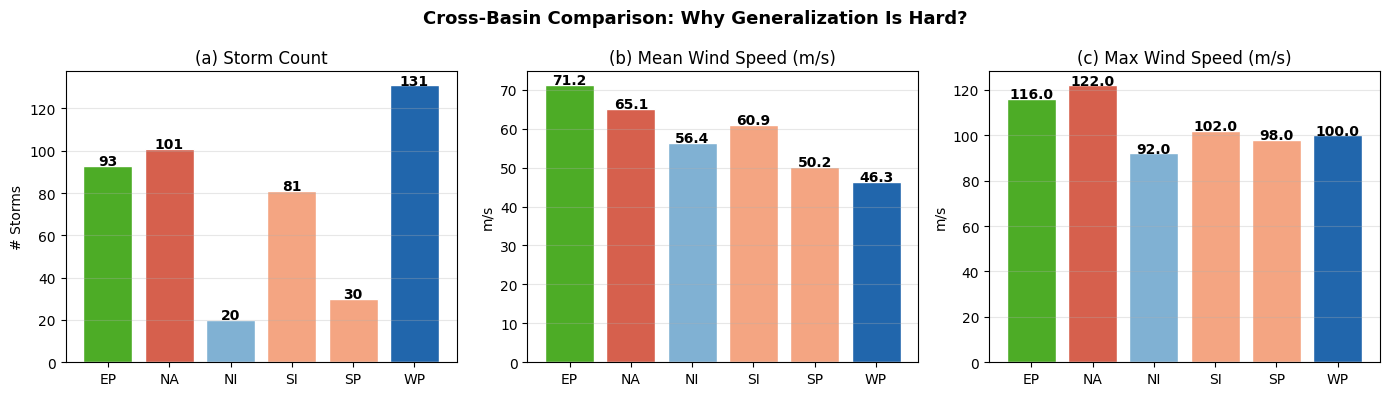

Saved: fig6_basin_comparison.png


In [69]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Cross-Basin Comparison: Why Generalization Is Hard?', fontsize=13, fontweight='bold')

# (a) Storm count
ax = axes[0]
storms_per_basin = [df_all[df_all.basin==b]['tc_name'].nunique() for b in BASINS]
ax.bar(BASINS, storms_per_basin, color=[COLORS[b] for b in BASINS], edgecolor='white')
ax.set_title('(a) Storm Count')
ax.set_ylabel('# Storms')
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(storms_per_basin):
    ax.text(i, v+0.3, str(v), ha='center', fontweight='bold')

# (b) Mean wind speed
ax = axes[1]
mean_wind = [df_all[df_all.basin==b].wnd_ms.mean() for b in BASINS]
ax.bar(BASINS, mean_wind, color=[COLORS[b] for b in BASINS], edgecolor='white')
ax.set_title('(b) Mean Wind Speed (m/s)')
ax.set_ylabel('m/s')
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(mean_wind):
    ax.text(i, v+0.2, f'{v:.1f}', ha='center', fontweight='bold')

# (c) Max wind speed
ax = axes[2]
max_wind = [df_all[df_all.basin==b].wnd_ms.max() for b in BASINS]
ax.bar(BASINS, max_wind, color=[COLORS[b] for b in BASINS], edgecolor='white')
ax.set_title('(c) Max Wind Speed (m/s)')
ax.set_ylabel('m/s')
ax.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(max_wind):
    ax.text(i, v+0.2, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_basin_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig6_basin_comparison.png')

## 9. Print All Statistics for Proposal

In [68]:
print('=' * 60)
print('TCND Test Subset — Summary Statistics')
print('=' * 60)
print(f'Total timesteps (all basins):  {len(df_all):,}')
print(f'Total unique storms:           {df_all.groupby(["basin","tc_name"]).ngroups}')
print(f'Year range:                    {df_all.year.min()}–{df_all.year.max()}')
print()
print(stats_df.to_string(index=False))
print()
print('Modalities:')
print('  Data1D  — tabular: LAT, LON, PRES, WND per 6h timestep')
print('  Data3D  — spatial: SST(81×81), z/u/v at 200/500/850/925 hPa (81×81)')
print('  Env-Data — synoptic: one-hot month/area/intensity + steering vectors')
print()
print('Task: Predict future_inte_change24 (4-class intensity trend)')
print('      Train on WP+NA+EP → zero-shot transfer to SI')

TCND Test Subset — Summary Statistics
Total timesteps (all basins):  16,110
Total unique storms:           456
Year range:                    2017–2023

Basin  Storms  Timesteps Wind mean (m/s) Wind max (m/s) Pressure min (hPa)      Latitude range
   EP      93       3345            71.2          116.0               -524    -828.0°–33336.0°
   NA     101       3900            65.1          122.0               -524   27792.0°–63900.0°
   NI      20        527            56.4           92.0               -413 -50272.2°–-32580.0°
   SI      81       2854            60.9          102.0               -636 -54126.0°–-17114.4°
   SP      30        922            50.2           98.0               -524   -17100.0°–6876.0°
   WP     131       4562            46.3          100.0               -426   -30204.0°–-936.0°

Modalities:
  Data1D  — tabular: LAT, LON, PRES, WND per 6h timestep
  Data3D  — spatial: SST(81×81), z/u/v at 200/500/850/925 hPa (81×81)
  Env-Data — synoptic: one-hot month/area/